In [2]:
# !pip install datasets

  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 4.5 MB/s  0:00:006m0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 3.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 6.6 MB/s  0:00:00 eta 0:00:01
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached shellingham-1.5.4-py2.py3-none-any.whl (9.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [datasets]/17 [datasets]ce-hub]


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset

In [5]:
# Load the standard SAMSum dataset
dataset = load_dataset("knkarthick/samsum")

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

validation.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/14731 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/818 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/819 [00:00<?, ? examples/s]

In [6]:
# Unpack into separate variables
train_data = dataset['train']
test_data = dataset['test']
val_data = dataset['validation']

In [8]:
df_train = pd.DataFrame(train_data)

In [11]:
df_train.info()
df_train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14731 entries, 0 to 14730
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            14731 non-null  object
 1   dialogue      14731 non-null  object
 2   summary       14731 non-null  object
 3   dialogue_len  14731 non-null  int64 
 4   summary_len   14731 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 575.6+ KB


,id,dialogue,summary,dialogue_len,summary_len
0,13818513,Amanda: I baked cookies. Do you want some?\nJ...,Amanda baked cookies and will bring Jerry some...,92,56
1,13728867,Olivia: Who are you voting for in this electio...,Olivia and Olivier are voting for liberals in ...,108,61
2,13681000,"Tim: Hi, what's up?\nKim: Bad mood tbh, I was ...",Kim may try the pomodoro technique recommended...,519,77
3,13730747,"Edward: Rachel, I think I'm in ove with Bella....",Edward thinks he is in love with Bella. Rachel...,152,97
4,13728094,Sam: hey overheard rick say something\nSam: i...,"Sam is confused, because he overheard Rick com...",888,145


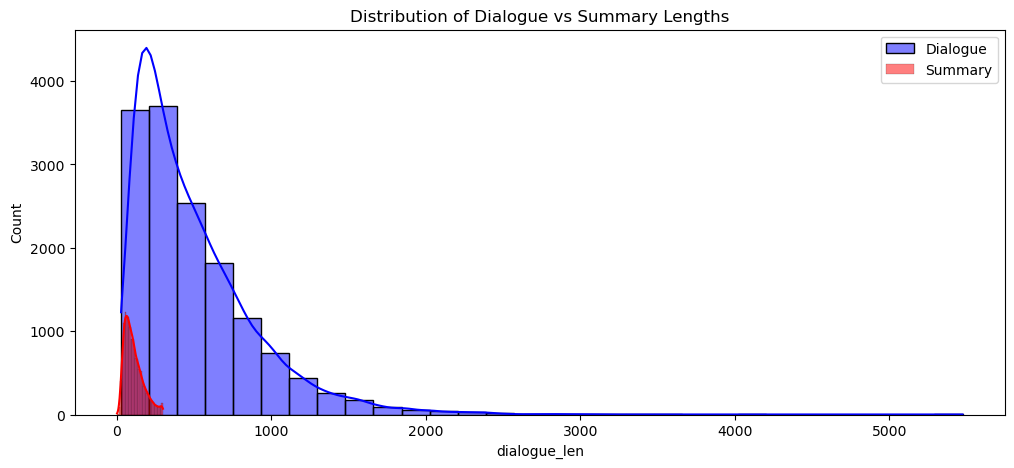

       dialogue_len   summary_len
count  14731.000000  14731.000000
mean     502.307922    110.139027
std      397.639839     60.891699
min       29.000000      3.000000
25%      212.000000     63.000000
50%      392.000000     96.000000
75%      681.000000    144.000000
max     5474.000000    300.000000


In [10]:
# Calculate character counts
df_train['dialogue_len'] = df_train['dialogue'].apply(len)
df_train['summary_len'] = df_train['summary'].apply(len)

# Visualize the distribution
plt.figure(figsize=(12, 5))
sns.histplot(df_train['dialogue_len'], bins=30, kde=True, color='blue', label='Dialogue')
sns.histplot(df_train['summary_len'], bins=30, kde=True, color='red', label='Summary')
plt.title("Distribution of Dialogue vs Summary Lengths")
plt.legend()
plt.show()

# Get statistical summary (mean, max, std)
print(df_train[['dialogue_len', 'summary_len']].describe())
